# Analyzing Rooftop Solar Potential Across Hamburg Districts

### Team Members
- Bahareh Fatemi
- Dhrupti Pambhar
- Zainab Olufunke Olukoga

In [2]:
!pip install geopandas

In [3]:
!pip install -q geopandas gdown

In [4]:
import pandas as pd
import geopandas as gpd
import gdown
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# =========================
# Data Sources
# =========================

CSV_FILE_ID = "1jACCV_pmh4B07l7eeSDqFFDVV2hi9Gq4"

HAMBURG_DISTRICTS_URL = (
    "https://gist.githubusercontent.com/Kilie/"
    "179dca3a1dfd103be692357160a7c8be/raw/"
    "hamburg_city_districts.geojson"
)

# =========================
# Load Solar Dataset
# =========================

gdown.download(
    f"https://drive.google.com/uc?id={CSV_FILE_ID}",
    "solar.csv",
    quiet=False
)

df = pd.read_csv("solar.csv", sep=";")

# =========================
# Load Hamburg Districts
# =========================

gdf = gpd.read_file(HAMBURG_DISTRICTS_URL)

Downloading...
From (original): https://drive.google.com/uc?id=1jACCV_pmh4B07l7eeSDqFFDVV2hi9Gq4
From (redirected): https://drive.google.com/uc?id=1jACCV_pmh4B07l7eeSDqFFDVV2hi9Gq4&confirm=t&uuid=4db79714-8146-4b0d-8cc4-3605075e7b84
To: /content/solar.csv
100%|██████████| 224M/224M [00:01<00:00, 116MB/s]


## **Data Source**
- We got our primary dataset from the Hamburg Transparency Portal website and downloaded the "Solar potential areas in Hamburg" dataset https://suche.transparenz.hamburg.de/dataset/solarpotenzialflaechen-hamburg9?utm_
- It contains: building-level solar potential, solar suitability, address/location, power estimates, usable PV area, geometric polygons.
- We however noticed that the address column only contained street names and Hamburg city, but NOT explicit district names.
- We needed a reference dataset to help us identify Hamburg districts, assign buildings to districts and enable maps. So we got the Hamburg district dataset from github https://gist.github.com/Kilie/179dca3a1dfd103be692357160a7c8be?utm_ to be combined with our primary dataset.
- It is a GeoJSON file which contained: Hamburg Districts and Geometric polygons

In [6]:
# =========================
# Explore Solar Dataset
# =========================

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nPreview:")
display(df.head())

Rows: 384,908
Columns: 11

Columns:
['_fid', 'address', 'eignung', 'eignung_t', 'calcurl_pv', 'calcurl_st', 'buildingid', 'power', 'pvarea', 'geom', 'coordinate_reference_system']

Data Types:
_fid                            object
address                         object
eignung                         object
eignung_t                       object
calcurl_pv                      object
calcurl_st                      object
buildingid                       int64
power                          float64
pvarea                         float64
geom                            object
coordinate_reference_system     object
dtype: object

Preview:


,_fid,address,eignung,eignung_t,calcurl_pv,calcurl_st,buildingid,power,pvarea,geom,coordinate_reference_system
0,DE.HH.UP_GEBAEUDE_769817,,"Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,136227,7.104031,47.36,"POLYGON ((9.957433 53.550834,9.957364 53.55086...",EPSG:4326
1,DE.HH.UP_GEBAEUDE_769818,"Neuer Steinweg 2, Hamburg","Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,137325,10.919474,160.79,"POLYGON ((9.978763 53.550701,9.979000 53.55073...",EPSG:4326
2,DE.HH.UP_GEBAEUDE_769819,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,137326,90.496715,1076.20,"POLYGON ((9.963214 53.536490,9.963219 53.53649...",EPSG:4326
3,DE.HH.UP_GEBAEUDE_769820,"Simon-von-Utrecht-Straße 66, Hamburg","Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,138967,18.852030,223.96,"POLYGON ((9.965540 53.550779,9.965540 53.55082...",EPSG:4326
4,DE.HH.UP_GEBAEUDE_769821,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,143796,16.407141,190.14,"POLYGON ((9.912257 53.517027,9.912099 53.51709...",EPSG:4326


In [7]:
# =========================
# Explore Hamburg Districts
# =========================

print("GeoDataFrame Shape:")
print(gdf.shape)

print("\nColumns:")
print(gdf.columns.tolist())

print("\nPreview:")
display(gdf.head())

GeoDataFrame Shape:
(104, 2)

Columns:
['Stadtteil', 'geometry']

Preview:


,Stadtteil,geometry
0,Allermöhe,"MULTIPOLYGON (((10.12579 53.49475, 10.1253 53...."
1,Alsterdorf,"MULTIPOLYGON (((10.01711 53.61586, 10.01692 53..."
2,Altengamme,"MULTIPOLYGON (((10.26913 53.46785, 10.26895 53..."
3,Altenwerder,"MULTIPOLYGON (((9.93921 53.51667, 9.93885 53.5..."
4,Altona-Altstadt,"MULTIPOLYGON (((9.94615 53.56273, 9.94612 53.5..."


(104, 2)
Index(['Stadtteil', 'geometry'], dtype='object')


<Axes: >

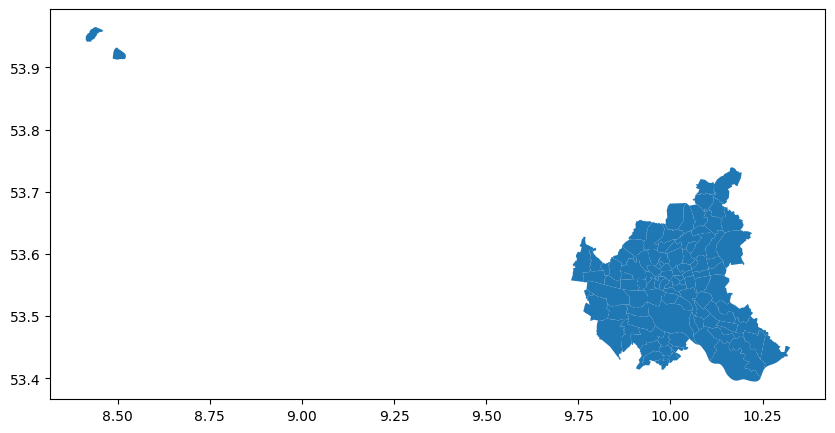

In [8]:
print(gdf.shape)
print(gdf.columns)
gdf.plot(figsize=(10,10))

# **Check data types**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384908 entries, 0 to 384907
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   _fid                         384908 non-null  object 
 1   address                      384908 non-null  object 
 2   eignung                      384908 non-null  object 
 3   eignung_t                    384908 non-null  object 
 4   calcurl_pv                   384908 non-null  object 
 5   calcurl_st                   384908 non-null  object 
 6   buildingid                   384908 non-null  int64  
 7   power                        384908 non-null  float64
 8   pvarea                       384908 non-null  float64
 9   geom                         384908 non-null  object 
 10  coordinate_reference_system  384908 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 32.3+ MB


In [10]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Stadtteil  104 non-null    object  
 1   geometry   104 non-null    geometry
dtypes: geometry(1), object(1)
memory usage: 1.8+ KB


# **Check missing values**

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
_fid,0
address,0
eignung,0
eignung_t,0
calcurl_pv,0
calcurl_st,0
buildingid,0
power,0
pvarea,0
geom,0


# **Check duplicated values**

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['buildingid'].duplicated().sum()

np.int64(10)

In [14]:
df['_fid'].duplicated().sum()

np.int64(0)

In [15]:
duplicates =  df[
    df['buildingid'].duplicated(keep=False)
].sort_values('buildingid')
duplicates

,_fid,address,eignung,eignung_t,calcurl_pv,calcurl_st,buildingid,power,pvarea,geom,coordinate_reference_system
331338,DE.HH.UP_GEBAEUDE_1100879,,Eignung 6 (geringe Einstrahlung / weniger geei...,Eignung 6 (geringe Einstrahlung / weniger geei...,,,3488,0.000000,0.00,"POLYGON ((9.982384 53.471181,9.982383 53.47118...",EPSG:4326
331339,DE.HH.UP_GEBAEUDE_1100880,,Eignung 6 (geringe Einstrahlung / weniger geei...,Eignung 6 (geringe Einstrahlung / weniger geei...,,,3488,0.000000,0.00,"POLYGON ((9.982379 53.471168,9.982384 53.47118...",EPSG:4326
312782,DE.HH.UP_GEBAEUDE_1082582,,Eignung 8 (kein Gebäude erkannt (Boden)),Eignung 8 (kein Gebäude erkannt (Boden)),,,10742,0.000000,0.00,"POLYGON ((9.882350 53.578973,9.882362 53.57899...",EPSG:4326
312783,DE.HH.UP_GEBAEUDE_1082583,,Eignung 8 (kein Gebäude erkannt (Boden)),Eignung 8 (kein Gebäude erkannt (Boden)),,,10742,0.000000,0.00,"POLYGON ((9.882362 53.578993,9.882441 53.57913...",EPSG:4326
286636,DE.HH.UP_GEBAEUDE_1051435,,Eignung 8 (kein Gebäude erkannt (Boden)),Eignung 8 (kein Gebäude erkannt (Boden)),,,41675,0.000000,0.00,"POLYGON ((9.970817 53.564056,9.971513 53.56408...",EPSG:4326
236102,DE.HH.UP_GEBAEUDE_1051434,,Eignung 8 (kein Gebäude erkannt (Boden)),Eignung 8 (kein Gebäude erkannt (Boden)),,,41675,0.000000,0.00,"POLYGON ((9.970815 53.564056,9.970817 53.56405...",EPSG:4326
160865,DE.HH.UP_GEBAEUDE_926688,"Wandsbeker Chaussee 280, Hamburg","Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,132626,20.427025,122.56,"POLYGON ((10.059778 53.570153,10.059781 53.570...",EPSG:4326
160864,DE.HH.UP_GEBAEUDE_926687,"Wandsbeker Chaussee 280, Hamburg","Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,132626,20.427025,122.56,"POLYGON ((10.059500 53.570015,10.059528 53.569...",EPSG:4326
357279,DE.HH.UP_GEBAEUDE_1127011,,Eignung 6 (geringe Einstrahlung / weniger geei...,Eignung 6 (geringe Einstrahlung / weniger geei...,,,132866,0.000000,0.00,"POLYGON ((10.113227 53.540955,10.113255 53.541...",EPSG:4326
357278,DE.HH.UP_GEBAEUDE_1127010,,Eignung 6 (geringe Einstrahlung / weniger geei...,Eignung 6 (geringe Einstrahlung / weniger geei...,,,132866,0.000000,0.00,"POLYGON ((10.113227 53.540955,10.113227 53.540...",EPSG:4326


- We noticed that the buildingid column has 10 duplicates, however, these duplicates differ by the _fid and geom columns.
- We decided that 10 out of 384,908 rows is quite negligible and should not affect our analysis, so we left the duplicates.

In [16]:
df.describe()

,buildingid,power,pvarea
count,384908.000000,384908.000000,384908.000000
mean,192468.866389,11.942373,107.646943
std,111127.480808,46.685994,510.973773
min,0.000000,0.000000,0.000000
25%,96234.750000,0.000000,2.950000
50%,192459.500000,5.069527,40.590000
75%,288685.250000,11.569463,90.200000
max,384993.000000,4905.518533,68588.560000


In [17]:
# Solar dataset
print(df.shape)
print(df.columns.tolist())

display(df.head())

(384908, 11)
['_fid', 'address', 'eignung', 'eignung_t', 'calcurl_pv', 'calcurl_st', 'buildingid', 'power', 'pvarea', 'geom', 'coordinate_reference_system']


,_fid,address,eignung,eignung_t,calcurl_pv,calcurl_st,buildingid,power,pvarea,geom,coordinate_reference_system
0,DE.HH.UP_GEBAEUDE_769817,,"Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,136227,7.104031,47.36,"POLYGON ((9.957433 53.550834,9.957364 53.55086...",EPSG:4326
1,DE.HH.UP_GEBAEUDE_769818,"Neuer Steinweg 2, Hamburg","Eignung 2 (geeignet, hohe Einstrahlung)","Eignung 2 (geeignet, hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,137325,10.919474,160.79,"POLYGON ((9.978763 53.550701,9.979000 53.55073...",EPSG:4326
2,DE.HH.UP_GEBAEUDE_769819,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,137326,90.496715,1076.20,"POLYGON ((9.963214 53.536490,9.963219 53.53649...",EPSG:4326
3,DE.HH.UP_GEBAEUDE_769820,"Simon-von-Utrecht-Straße 66, Hamburg","Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,138967,18.852030,223.96,"POLYGON ((9.965540 53.550779,9.965540 53.55082...",EPSG:4326
4,DE.HH.UP_GEBAEUDE_769821,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)","Eignung 1 (geeignet, sehr hohe Einstrahlung)",https://hamburg.o.geoplex.de/solar/app?buildin...,https://hamburg.o.geoplex.de/solar/app?buildin...,143796,16.407141,190.14,"POLYGON ((9.912257 53.517027,9.912099 53.51709...",EPSG:4326


# **Create Clean Dataset**

In [18]:
# Create Clean Dataset
solar_clean = df.copy()

# **Remove Unnecessary Columns**

In [19]:
columns_to_drop = [
    "_fid",
    "eignung",
    "calcurl_pv",
    "calcurl_st",
    "coordinate_reference_system"
]

solar_clean = solar_clean.drop(columns=columns_to_drop)

In [20]:
solar_clean.columns

Index(['address', 'eignung_t', 'buildingid', 'power', 'pvarea', 'geom'], dtype='object')

# **Rename Columns**

In [21]:
# Rename columns
# we would like to give the dataset English names/Standardize Names and Labels
solar_clean.rename(
    columns={
        "buildingid": "building_id",
        "eignung_t": "suitability",
        "power": "solar_power_kwp",
        "pvarea": "solar_pvarea_m2",
        "geom": "geometry"
    },
    inplace=True
)

In [22]:
solar_clean.head()

,address,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry
0,,"Eignung 2 (geeignet, hohe Einstrahlung)",136227,7.104031,47.36,"POLYGON ((9.957433 53.550834,9.957364 53.55086..."
1,"Neuer Steinweg 2, Hamburg","Eignung 2 (geeignet, hohe Einstrahlung)",137325,10.919474,160.79,"POLYGON ((9.978763 53.550701,9.979000 53.55073..."
2,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)",137326,90.496715,1076.20,"POLYGON ((9.963214 53.536490,9.963219 53.53649..."
3,"Simon-von-Utrecht-Straße 66, Hamburg","Eignung 1 (geeignet, sehr hohe Einstrahlung)",138967,18.852030,223.96,"POLYGON ((9.965540 53.550779,9.965540 53.55082..."
4,,"Eignung 1 (geeignet, sehr hohe Einstrahlung)",143796,16.407141,190.14,"POLYGON ((9.912257 53.517027,9.912099 53.51709..."


#####Eignung 1 (very high solar irradiation)    108,838
#####Eignung 2 (high solar irradiation)         107,258
#####Eignung 3 (medium solar irradiation)        59,618
#####Eignung 6 (low irradiation)                 99,799

##### Number of buildings: 384,908
##### Number of districts: 104
##### 108,838 + 107,258 = 216,096 buildings

# **Result:**
- More than 216,000 buildings are highly suitable for solar energy.
- More than half of Hamburg's buildings show high or very high suitability for photovoltaic installations.

### **SCHEMA**
- **address**: building address, geographic location reference.
- **suitability**: suitability category. How appropriate the building rooftop is for solar installation.
- **building_id**: unique building id
- **solar_power_kwp**: estimated solar power potential in kilowatt-peak (kWp), 1 kWp = 1,000 watts peak.
- **solar_pvarea_m2**: usable photovoltaic rooftop area available for solar panel installation measured in square meters.
- **geometry**: geographic polygon, building spatial coordinates for maps.

# **Translate Suitability Categories**

In [23]:
# Translate suitability labels
suitability_map = {
    "Eignung 1 (geeignet, sehr hohe Einstrahlung)": "Very High",
    "Eignung 2 (geeignet, hohe Einstrahlung)": "High",
    "Eignung 3 (geeignet, mittlere Einstrahlung)": "Moderate",
    "Eignung 6 (geringe Einstrahlung / weniger geeignet / vor Ort zu prüfen)": "Low",
    "Eignung 8 (kein Gebäude erkannt (Boden))": "No Building",
    "Eignung 0 (Datenqualität unzureichend)": "Insufficient Data"
}

solar_clean["suitability"] = (
    solar_clean["suitability"]
    .map(suitability_map)
)

In [24]:
solar_clean["suitability"].value_counts()

,count
suitability,
Very High,108838
High,107258
Low,99799
Moderate,59618
No Building,9070
Insufficient Data,325


# **Check Address Column**

In [25]:
solar_clean["address"].head(20)

,address
0,
1,"Neuer Steinweg 2, Hamburg"
2,
3,"Simon-von-Utrecht-Straße 66, Hamburg"
4,
5,
6,"Kohlhöfen 15, Hamburg"
7,"Brigittenstraße 10, Hamburg"
8,"Bernstorffstraße 36, Hamburg"
9,"Budapester Straße 44, Hamburg"


In [26]:
empty_addresses = solar_clean["address"].str.strip().eq("").sum()

empty_percentage = empty_addresses / len(solar_clean) * 100

print(empty_addresses)
print(f"{empty_percentage:.2f}%")

160589
41.72%


In [27]:
solar_clean = solar_clean.drop(columns=["address"])

In [28]:
solar_clean

,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry
0,High,136227,7.104031,47.36,"POLYGON ((9.957433 53.550834,9.957364 53.55086..."
1,High,137325,10.919474,160.79,"POLYGON ((9.978763 53.550701,9.979000 53.55073..."
2,Very High,137326,90.496715,1076.20,"POLYGON ((9.963214 53.536490,9.963219 53.53649..."
3,Very High,138967,18.852030,223.96,"POLYGON ((9.965540 53.550779,9.965540 53.55082..."
4,Very High,143796,16.407141,190.14,"POLYGON ((9.912257 53.517027,9.912099 53.51709..."
...,...,...,...,...,...
384903,Low,340751,0.000000,0.00,"POLYGON ((10.210937 53.518367,10.210898 53.518..."
384904,Low,340815,0.000000,0.00,"POLYGON ((10.212104 53.515508,10.212169 53.515..."
384905,Low,340984,0.000000,0.50,"POLYGON ((10.210733 53.518329,10.210702 53.518..."
384906,Low,341047,0.000000,0.00,"POLYGON ((10.210685 53.518980,10.210656 53.519..."


# **EDA Visualizations:**

# **Suitability Distribution**

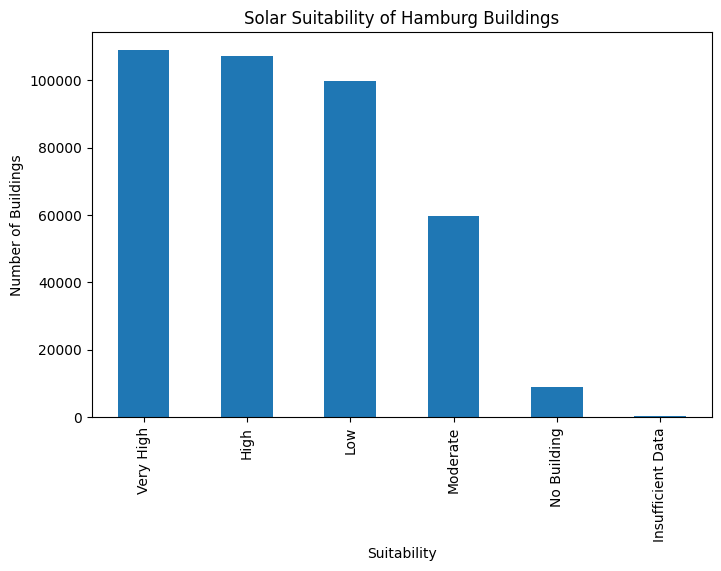

In [29]:
# To show us what proportion of Hamburg buildings are suitable for rooftop solar installation.

plt.figure(figsize=(8,5))

solar_clean["suitability"].value_counts().plot(
    kind="bar"
)

plt.title("Solar Suitability of Hamburg Buildings")
plt.xlabel("Suitability")
plt.ylabel("Number of Buildings")

plt.show()

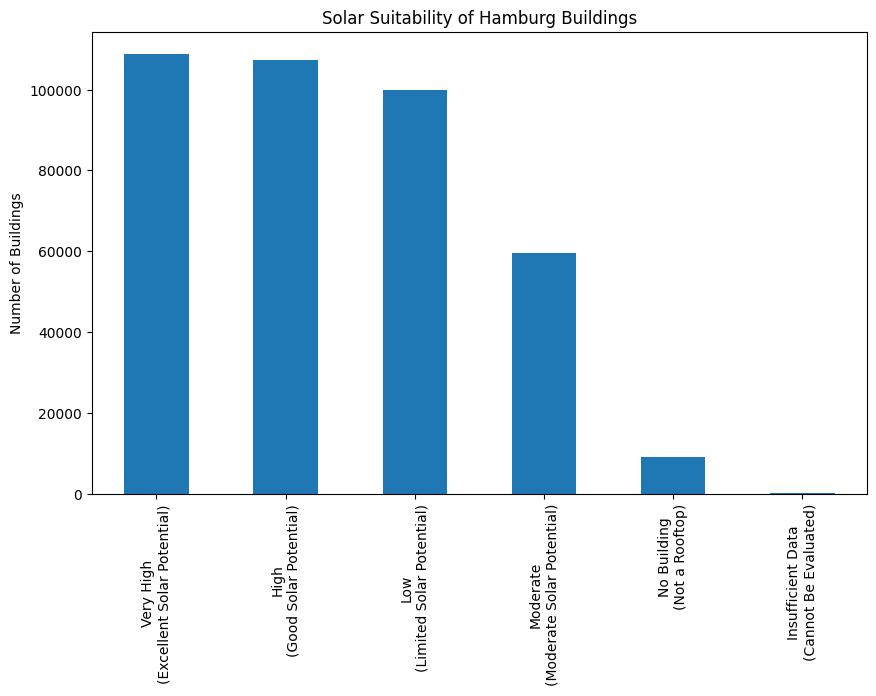

In [30]:
label_map = {
    "Very High": "Very High\n(Excellent Solar Potential)",
    "High": "High\n(Good Solar Potential)",
    "Moderate": "Moderate\n(Moderate Solar Potential)",
    "Low": "Low\n(Limited Solar Potential)",
    "No Building": "No Building\n(Not a Rooftop)",
    "Insufficient Data": "Insufficient Data\n(Cannot Be Evaluated)"
}

counts = solar_clean["suitability"].value_counts()

counts.index = [label_map[x] for x in counts.index]

counts.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Solar Suitability of Hamburg Buildings")
plt.ylabel("Number of Buildings")
plt.show()

The dataset classifies each building according to its suitability for photovoltaic (PV) installation. Buildings in Categories 1 and 2 have the highest solar potential and are considered the most favorable for solar energy generation. Category 3 indicates moderate suitability, while Category 6 represents limited solar potential. Categories 0 and 8 were excluded from the analysis because they either lacked sufficient data or did not correspond to actual buildings.

# **Distribution of Solar Area**

In [31]:
solar_clean["solar_pvarea_m2"].describe()

,solar_pvarea_m2
count,384908.000000
mean,107.646943
std,510.973773
min,0.000000
25%,2.950000
50%,40.590000
75%,90.200000
max,68588.560000


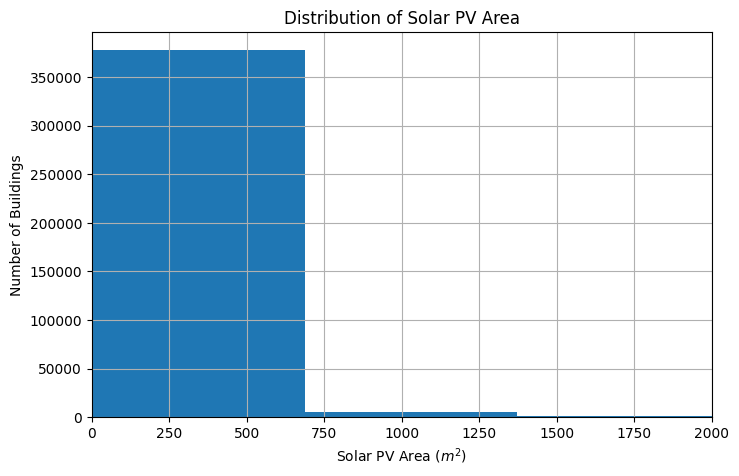

In [32]:
# To show how much rooftop area is typically available for solar panel installations in Hamburg.

plt.figure(figsize=(8,5))

solar_clean["solar_pvarea_m2"].hist(
    bins=100
)

plt.title("Distribution of Solar PV Area")
plt.xlabel("Solar PV Area ($m^2$)")
plt.ylabel("Number of Buildings")
plt.xlim(0, 2000)

plt.show()

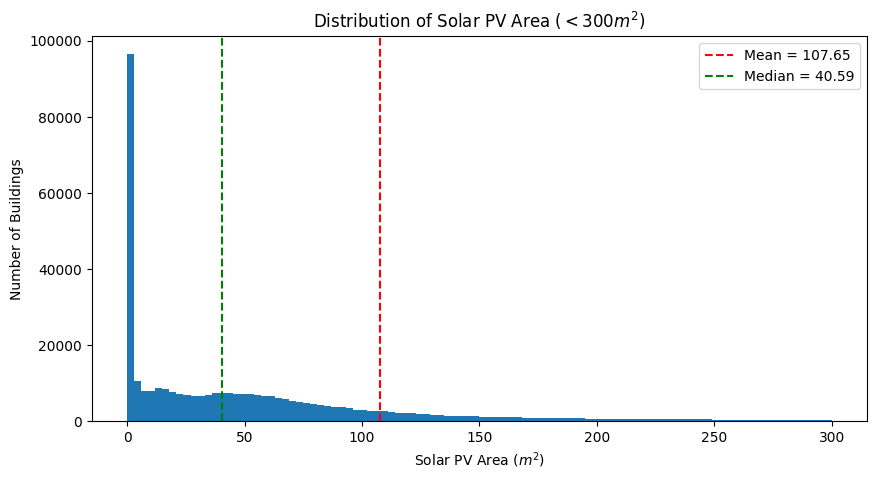

In [33]:
mean_pvarea = solar_clean["solar_pvarea_m2"].mean()
median_pvarea = solar_clean["solar_pvarea_m2"].median()

plt.figure(figsize=(10,5))

plt.hist(solar_clean[solar_clean["solar_pvarea_m2"] < 300]["solar_pvarea_m2"], bins=100)

plt.axvline(mean_pvarea,
            color="red",
            linestyle="--",
            label=f"Mean = {mean_pvarea:.2f}")

plt.axvline(median_pvarea,
            color="green",
            linestyle="--",
            label=f"Median = {median_pvarea:.2f}")
plt.title("Distribution of Solar PV Area ($<300 m^2$)")
plt.xlabel("Solar PV Area ($m^2$)")
plt.ylabel("Number of Buildings")
plt.legend()
plt.show()

# **Distribution of Solar Power**

In [34]:
solar_clean["solar_power_kwp"].describe()

,solar_power_kwp
count,384908.000000
mean,11.942373
std,46.685994
min,0.000000
25%,0.000000
50%,5.069527
75%,11.569463
max,4905.518533


Mean > Median

This indicates a right-skewed distribution.

Most buildings have relatively low solar power potential, while a small number of very large buildings have extremely high potential.

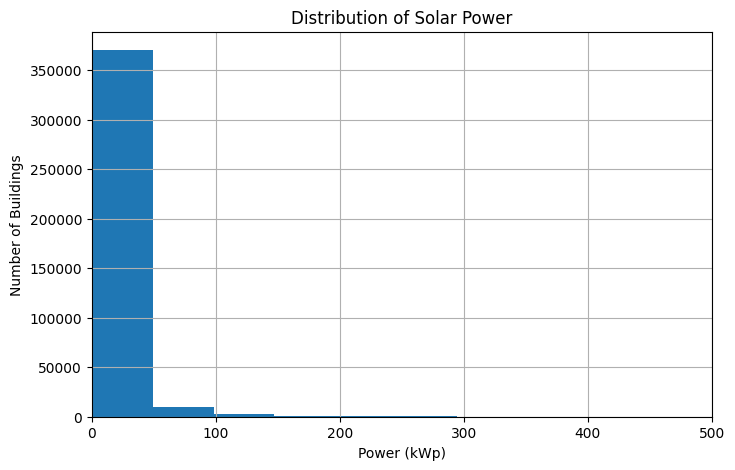

In [35]:
#To show if most Hamburg buildings have low or high rooftop solar power potential.

plt.figure(figsize=(8,5))

solar_clean["solar_power_kwp"].hist(
    bins=100
)

plt.title("Distribution of Solar Power")
plt.xlabel("Power (kWp)")
plt.ylabel("Number of Buildings")
plt.xlim(0, 500)

plt.show()

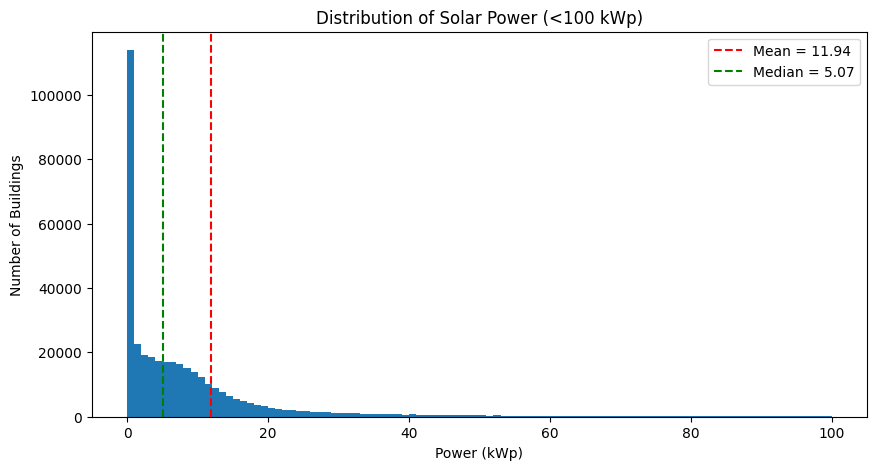

In [36]:
mean_power = solar_clean["solar_power_kwp"].mean()
median_power = solar_clean["solar_power_kwp"].median()

plt.figure(figsize=(10,5))

plt.hist(solar_clean[solar_clean["solar_power_kwp"] < 100]["solar_power_kwp"], bins=100)

plt.axvline(mean_power,
            color="red",
            linestyle="--",
            label=f"Mean = {mean_power:.2f}")

plt.axvline(median_power,
            color="green",
            linestyle="--",
            label=f"Median = {median_power:.2f}")
plt.title("Distribution of Solar Power (<100 kWp)")
plt.xlabel("Power (kWp)")
plt.ylabel("Number of Buildings")
plt.legend()
plt.show()

# **Solar Power Potential (power)**

# **Solar Panel Area (pvarea)**

Mean > Median

Most buildings have relatively small usable roof areas, but a few buildings have enormous rooftop surfaces.

# **Interesting Finding**


25% power = 0

25% pvarea = 2.95

This means that at least a quarter of the buildings have:
- no meaningful solar potential
- or very little usable roof area

This aligns with the suitability categories:
Eignung 6
Eignung 8
Eignung 0

In [37]:
solar_clean[["solar_pvarea_m2", "solar_power_kwp"]].corr()

,solar_pvarea_m2,solar_power_kwp
solar_pvarea_m2,1.00000,0.96937
solar_power_kwp,0.96937,1.00000


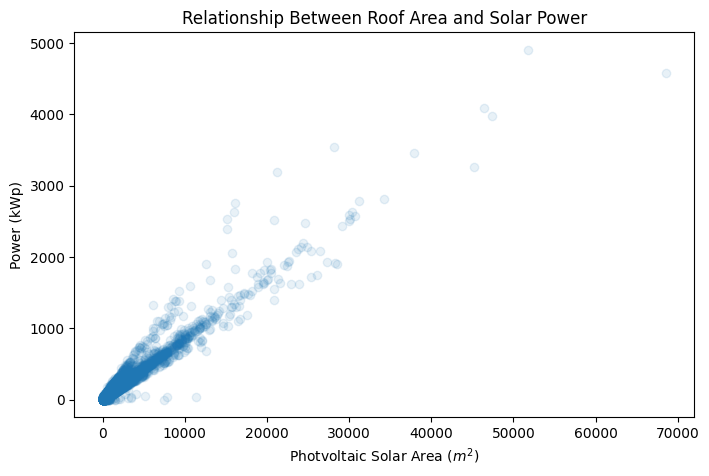

In [38]:
# This shows us if larger rooftop PV area lead to greater solar power potential,
# i.e relationship between PV Area and Solar Potential

plt.figure(figsize=(8,5))
plt.scatter(
    solar_clean["solar_pvarea_m2"],
    solar_clean["solar_power_kwp"],
    alpha=0.1
)

plt.xlabel("Photvoltaic Solar Area ($m^2$)")
plt.ylabel("Power (kWp)")
plt.title("Relationship Between Roof Area and Solar Power")
plt.show()

Most buildings in Hamburg have relatively small rooftop solar potential. However, a small number of very large buildings, such as warehouses or industrial facilities, have extremely high solar potential and contribute significantly to the city's overall solar energy capacity.

In [39]:
summary = pd.DataFrame({
    "Metric": [
        "Buildings",
        "Average Solar Area",
        "Average Solar Power",
        "Maximum Solar Area",
        "Maximum Solar Power"
    ],
    "Value": [
        len(solar_clean),
        solar_clean["solar_pvarea_m2"].mean(),
        solar_clean["solar_power_kwp"].mean(),
        solar_clean["solar_pvarea_m2"].max(),
        solar_clean["solar_power_kwp"].max()
    ]
})

summary

,Metric,Value
0,Buildings,384908.000000
1,Average Solar Area,107.646943
2,Average Solar Power,11.942373
3,Maximum Solar Area,68588.560000
4,Maximum Solar Power,4905.518533


**********************************************************************

# **Hamburg districts**

In [40]:
# Hamburg districts
print(gdf.shape)
print(gdf.columns.tolist())

display(gdf.head())

(104, 2)
['Stadtteil', 'geometry']


,Stadtteil,geometry
0,Allermöhe,"MULTIPOLYGON (((10.12579 53.49475, 10.1253 53...."
1,Alsterdorf,"MULTIPOLYGON (((10.01711 53.61586, 10.01692 53..."
2,Altengamme,"MULTIPOLYGON (((10.26913 53.46785, 10.26895 53..."
3,Altenwerder,"MULTIPOLYGON (((9.93921 53.51667, 9.93885 53.5..."
4,Altona-Altstadt,"MULTIPOLYGON (((9.94615 53.56273, 9.94612 53.5..."


In [41]:
# shows the bounds of all geometries in the GeoDataFrame: [minx, miny, maxx, maxy]
gdf.total_bounds


array([ 8.41319041, 53.39501085, 10.3252768 , 53.96490623])

In [42]:
# Create clean districts dataset
districts_clean = gdf.copy()

# Rename column to English
districts_clean = districts_clean.rename(columns={
    "Stadtteil": "district"
})

# Check result
print(districts_clean.shape)
print(districts_clean.columns.tolist())
display(districts_clean.head())

(104, 2)
['district', 'geometry']


,district,geometry
0,Allermöhe,"MULTIPOLYGON (((10.12579 53.49475, 10.1253 53...."
1,Alsterdorf,"MULTIPOLYGON (((10.01711 53.61586, 10.01692 53..."
2,Altengamme,"MULTIPOLYGON (((10.26913 53.46785, 10.26895 53..."
3,Altenwerder,"MULTIPOLYGON (((9.93921 53.51667, 9.93885 53.5..."
4,Altona-Altstadt,"MULTIPOLYGON (((9.94615 53.56273, 9.94612 53.5..."


In [43]:
# To display the Coordinate Reference System (CRS).
#EPSG:4326 tells us it is the standard GPS coordinate system.

districts_clean.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# **Convert solar_clean geometry from text to real geometry and convert into GeoDataFrame**

##### Currently, the geometry column in the primary dataset is appearing as a text(object).
We need to convert it from text into actual geometry objects (geometry) to be able to perform a spatial join with the reference dataset.

##### So we import shapely's wkt (Well-Known Text) module.

This is a standard text format for representing geometric objects such as points, lines, and polygons.

In [44]:
from shapely import wkt

solar_clean["geometry"] = solar_clean["geometry"].apply(wkt.loads)

solar_gdf = gpd.GeoDataFrame(
    solar_clean,
    geometry="geometry",
    crs="EPSG:4326"
)

In [45]:
print(type(solar_gdf))
print(type(districts_clean))

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geodataframe.GeoDataFrame'>


In [46]:
print(solar_gdf.shape)
print(solar_gdf.crs)
solar_gdf.head()

(384908, 5)
EPSG:4326


,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry
0,High,136227,7.104031,47.36,"POLYGON ((9.95743 53.55083, 9.95736 53.55086, ..."
1,High,137325,10.919474,160.79,"POLYGON ((9.97876 53.5507, 9.979 53.55073, 9.9..."
2,Very High,137326,90.496715,1076.20,"POLYGON ((9.96321 53.53649, 9.96322 53.5365, 9..."
3,Very High,138967,18.852030,223.96,"POLYGON ((9.96554 53.55078, 9.96554 53.55082, ..."
4,Very High,143796,16.407141,190.14,"POLYGON ((9.91226 53.51703, 9.9121 53.51709, 9..."


# **Clean district GeoDataFrame**

In [47]:
districts_clean = gdf.copy()

districts_clean = districts_clean.rename(columns={
    "Stadtteil": "district"
})

print(districts_clean.shape)
print(districts_clean.crs)
districts_clean.head()

(104, 2)
EPSG:4326


,district,geometry
0,Allermöhe,"MULTIPOLYGON (((10.12579 53.49475, 10.1253 53...."
1,Alsterdorf,"MULTIPOLYGON (((10.01711 53.61586, 10.01692 53..."
2,Altengamme,"MULTIPOLYGON (((10.26913 53.46785, 10.26895 53..."
3,Altenwerder,"MULTIPOLYGON (((9.93921 53.51667, 9.93885 53.5..."
4,Altona-Altstadt,"MULTIPOLYGON (((9.94615 53.56273, 9.94612 53.5..."


# **Spatial join: assign each building to a district**

In [48]:
joined = gpd.sjoin(
    solar_gdf,
    districts_clean,
    how="inner",
    predicate="within"
)

print(joined.shape)
joined.head()

(384525, 7)


,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry,index_right,district
0,High,136227,7.104031,47.36,"POLYGON ((9.95743 53.55083, 9.95736 53.55086, ...",86,St.Pauli
1,High,137325,10.919474,160.79,"POLYGON ((9.97876 53.5507, 9.979 53.55073, 9.9...",65,Neustadt
2,Very High,137326,90.496715,1076.20,"POLYGON ((9.96321 53.53649, 9.96322 53.5365, 9...",88,Steinwerder
3,Very High,138967,18.852030,223.96,"POLYGON ((9.96554 53.55078, 9.96554 53.55082, ...",86,St.Pauli
4,Very High,143796,16.407141,190.14,"POLYGON ((9.91226 53.51703, 9.9121 53.51709, 9...",97,Waltershof


# **Summarize solar potential by district**

In [49]:
#We create a single aggregated dataset showing a district-level summary table
#from our spatially joined datasets.

district_summary = (
    joined
    .groupby("district")
    .agg(
        number_of_buildings=("building_id", "count"),
        total_solar_power_kwp=("solar_power_kwp", "sum"),
        avg_solar_power_kwp=('solar_power_kwp', 'mean'),
        total_solar_pvarea_m2=("solar_pvarea_m2", "sum"),
        avg_pv_area=('solar_pvarea_m2', 'mean')
    )
    .reset_index()
)

district_summary.head()

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area
0,Allermöhe,1578,49456.053444,31.340972,553940.23,351.039436
1,Alsterdorf,2629,29044.794638,11.047849,262940.83,100.015531
2,Altengamme,1617,16704.941494,10.330823,121865.86,75.365405
3,Altenwerder,462,48261.066993,104.461184,532831.47,1153.314870
4,Altona-Altstadt,1761,35806.103352,20.332824,325317.84,184.734719


In [50]:
# We add Solar-Suitable Building Counts
# We define: Very High, High and Moderate as our solar-ready buildings.

suitable_buildings = (
    joined[
        joined['suitability'].isin(
            ['Very High', 'High','Moderate']
        )
    ]
    .groupby("district")
    .size()
    .reset_index(name='suitable_buildings')
)

In [51]:
# we merge into the main district_summary

district_summary = district_summary.merge(
    suitable_buildings,
    on='district',
    how='inner'
)

district_summary['suitable_buildings'] = (
    district_summary['suitable_buildings']
    .fillna(0)
    .astype(int)
)

In [52]:
# We create a Suitability Percentage

district_summary['suitability_percentage'] = (
    district_summary['suitable_buildings']
    /
    district_summary['number_of_buildings']
    * 100
).round(2)
district_summary.head()

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage
0,Allermöhe,1578,49456.053444,31.340972,553940.23,351.039436,1190,75.41
1,Alsterdorf,2629,29044.794638,11.047849,262940.83,100.015531,1806,68.70
2,Altengamme,1617,16704.941494,10.330823,121865.86,75.365405,1232,76.19
3,Altenwerder,462,48261.066993,104.461184,532831.47,1153.314870,284,61.47
4,Altona-Altstadt,1761,35806.103352,20.332824,325317.84,184.734719,1443,81.94


In [53]:
district_summary.sort_values(
    "total_solar_power_kwp",
    ascending=False
).head(10)

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage
99,Wilhelmsburg,13022,206855.014315,15.885042,2038098.31,156.511927,9140,70.19
74,Rahlstedt,19239,196781.326661,10.228251,1700459.17,88.386048,14123,73.41
16,Bramfeld,11776,117400.204706,9.969447,952920.68,80.920574,8921,75.76
12,Billstedt,11737,116302.140550,9.909018,1047447.25,89.243184,8911,75.92
11,Billbrook,1910,112008.419598,58.643152,1275140.84,667.613005,1309,68.53
51,Langenhorn,13425,111482.141383,8.304070,905750.26,67.467431,9378,69.85
6,Bahrenfeld,6775,107215.797409,15.825210,1058324.62,156.210276,4504,66.48
66,Niendorf,12696,105017.673114,8.271713,861453.96,67.852391,9342,73.58
9,Bergedorf,9276,95047.804513,10.246637,850860.70,91.727113,6602,71.17
97,Wandsbek,5485,84879.252385,15.474795,786608.33,143.410817,4065,74.11


# **Map 1: Total Solar Power Potential by District**
# **Which districts could generate the most solar energy overall?**

In [54]:
district_summary.sort_values(
    "total_solar_power_kwp",
    ascending=False
).head(10)

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage
99,Wilhelmsburg,13022,206855.014315,15.885042,2038098.31,156.511927,9140,70.19
74,Rahlstedt,19239,196781.326661,10.228251,1700459.17,88.386048,14123,73.41
16,Bramfeld,11776,117400.204706,9.969447,952920.68,80.920574,8921,75.76
12,Billstedt,11737,116302.140550,9.909018,1047447.25,89.243184,8911,75.92
11,Billbrook,1910,112008.419598,58.643152,1275140.84,667.613005,1309,68.53
51,Langenhorn,13425,111482.141383,8.304070,905750.26,67.467431,9378,69.85
6,Bahrenfeld,6775,107215.797409,15.825210,1058324.62,156.210276,4504,66.48
66,Niendorf,12696,105017.673114,8.271713,861453.96,67.852391,9342,73.58
9,Bergedorf,9276,95047.804513,10.246637,850860.70,91.727113,6602,71.17
97,Wandsbek,5485,84879.252385,15.474795,786608.33,143.410817,4065,74.11


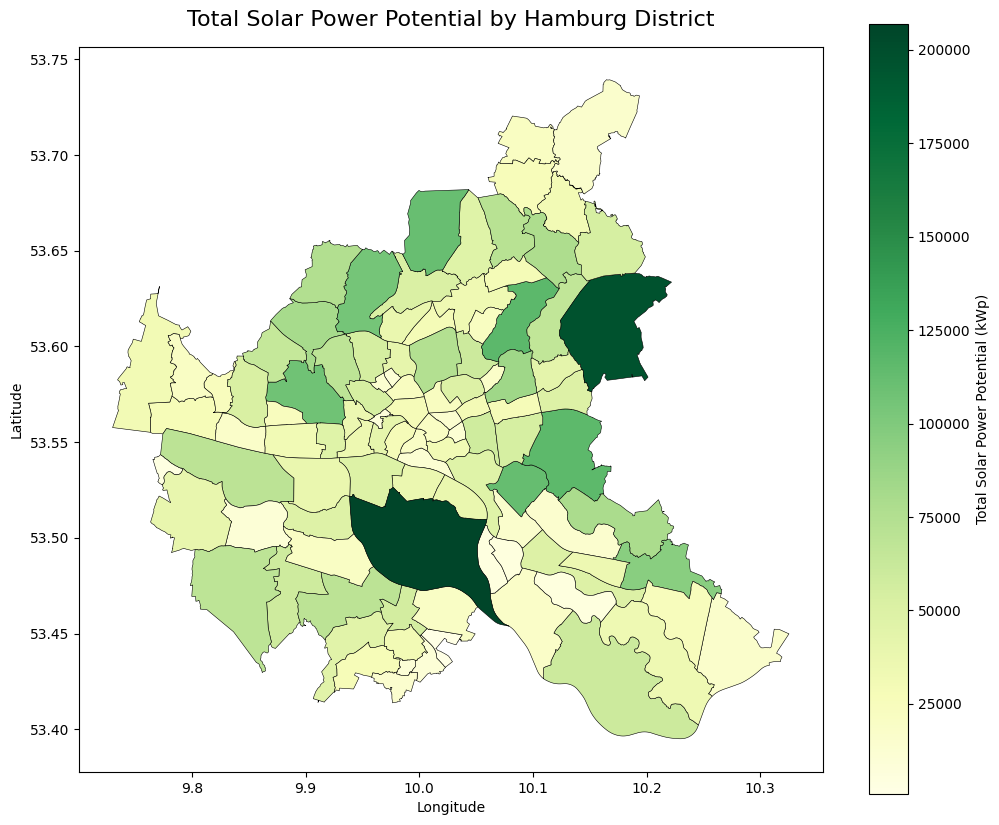

In [55]:
district_map = districts_clean.merge(
    district_summary,
    on="district"
)

district_map.plot(
    column="total_solar_power_kwp",
    figsize=(10,10),
    legend=True,
    legend_kwds={
        "label": "Total Solar Power Potential (kWp)"
    }
)
plt.title(
    "Total Solar Power Potential by Hamburg District",
    fontsize=16,
    pad=15
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

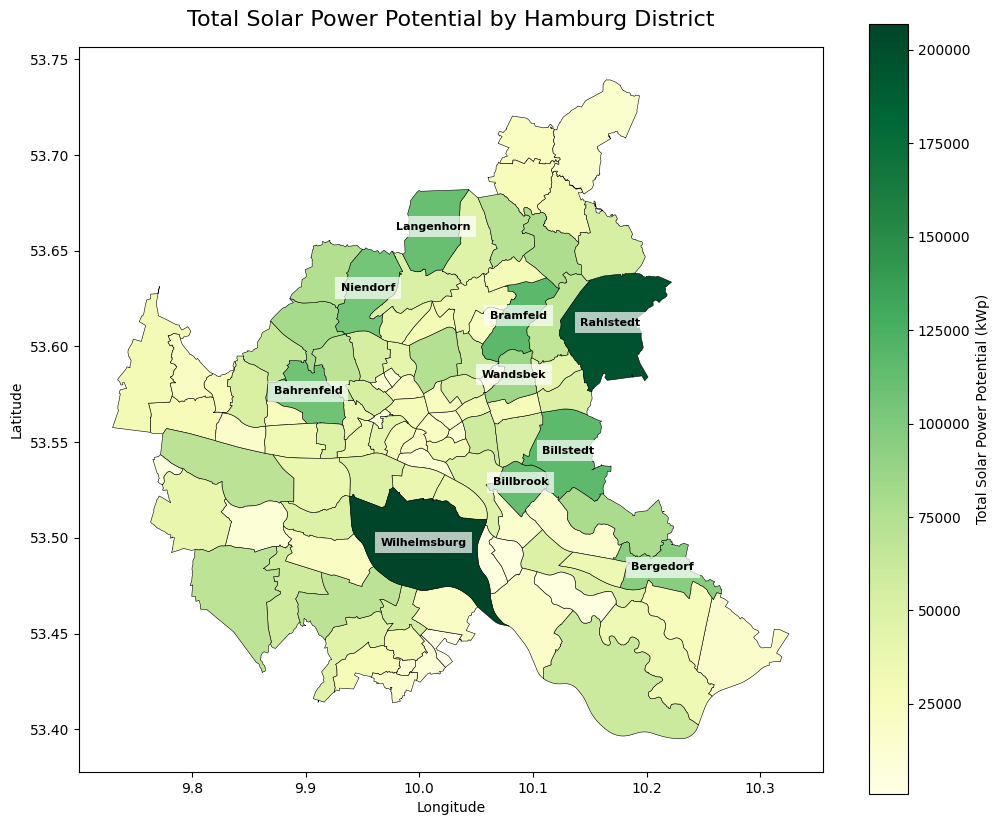

In [56]:
top10 = district_map.nlargest(10, "total_solar_power_kwp")

fig, ax = plt.subplots(figsize=(12, 10))

district_map.plot(
    column="total_solar_power_kwp",
    cmap="viridis",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Total Solar Power Potential (kWp)"
    }
)

for idx, row in top10.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax.annotate(
    text=row["district"],
    xy=(x, y),
    fontsize=8,
    fontweight="bold",
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        edgecolor="none"
    )
)

plt.title(
    "Total Solar Power Potential by Hamburg District",
    fontsize=16,
    pad=15
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# **Darker district = higher solar potential**
# **Lighter district = lower solar potential**
**The color intensity represents the total estimated solar power potential of buildings within each district. Darker colors indicate lower solar potential, while brighter colors indicate higher solar potential. Values are measured in kilowatt-peak (kWp), which represents the maximum potential electricity generation capacity of rooftop photovoltaic systems.**

*************************************************************************************

# **Map 2: Average Solar Power Potential per Building**
# **Which districts have the most solar-efficient buildings?**

In [57]:
district_map = districts_clean.merge(
    district_summary,
    on="district"
)

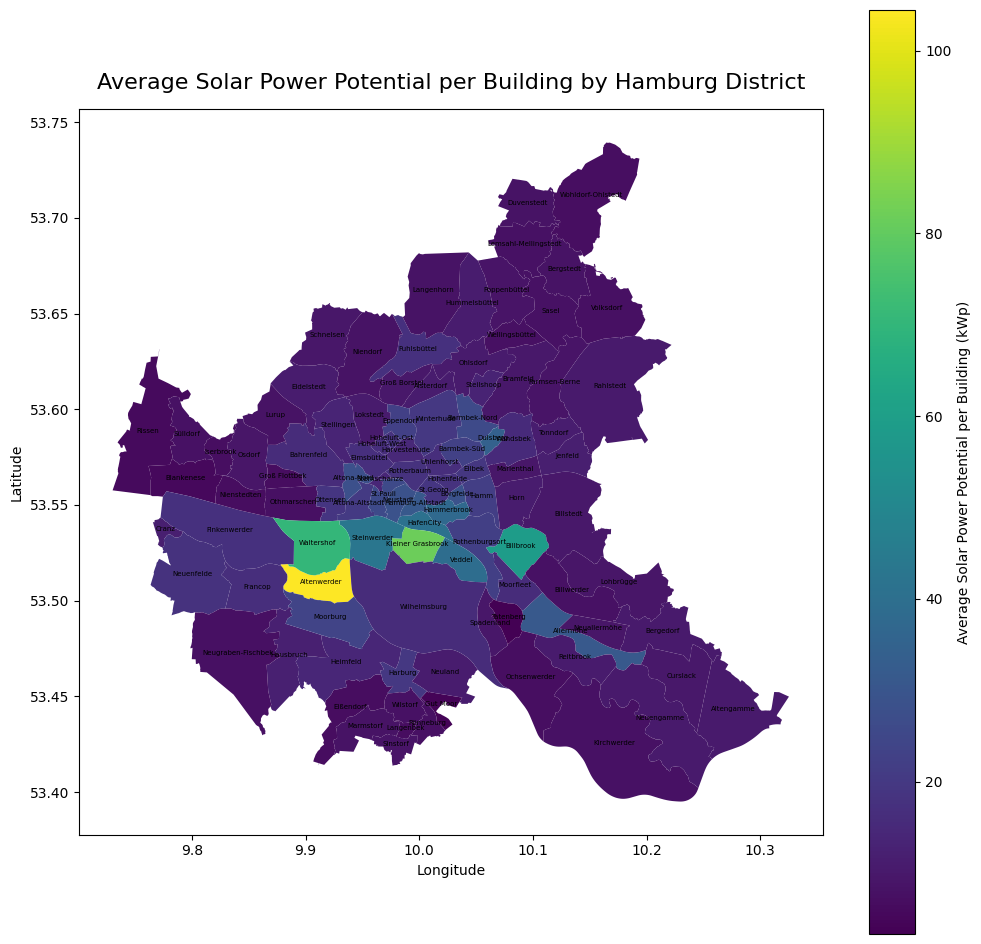

In [58]:
fig, ax = plt.subplots(figsize=(12,12))

district_map.plot(
    column="avg_solar_power_kwp",
    cmap="viridis",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Average Solar Power Potential per Building (kWp)"
    }
)

# Add district names
for idx, row in district_map.iterrows():
    centroid = row.geometry.centroid

    ax.annotate(
        text=row["district"],
        xy=(centroid.x, centroid.y),
        fontsize=5,
        ha="center"
    )

ax.set_title(
    "Average Solar Power Potential per Building by Hamburg District",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

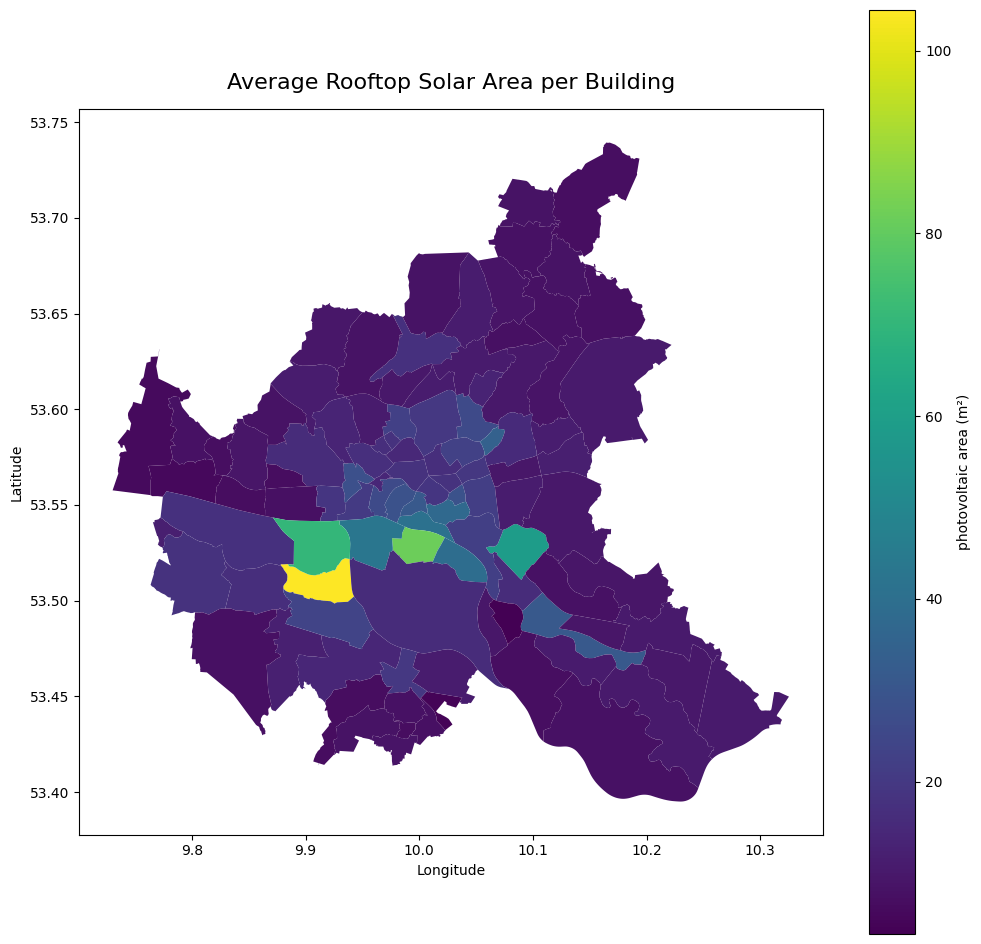

In [59]:
fig, ax = plt.subplots(figsize=(12,12))

district_map.plot(
    column="avg_solar_power_kwp",
    cmap="viridis",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "photovoltaic area (m2)"
    }
)

ax.set_title(
    "Average Rooftop Solar Area per Building",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

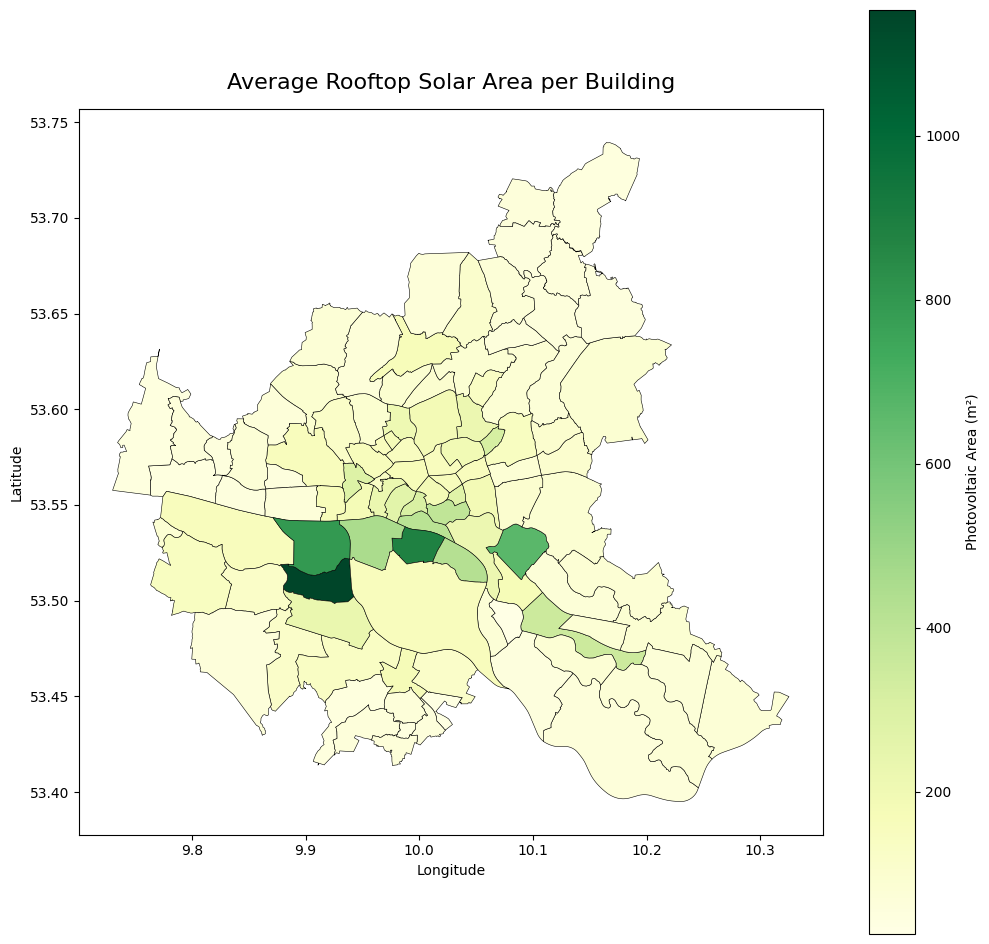

In [87]:
fig, ax = plt.subplots(figsize=(12,12))

district_map.plot(
    column="avg_solar_power_kwp",
    cmap="viridis",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "photovoltaic area (m2)"
    }
)

# Select Top 10 districts
top10 = district_map.nlargest(5, "avg_solar_power_kwp")

# Add labels only for Top 10
for idx, row in top10.iterrows():
    centroid = row.geometry.centroid

    ax.annotate(
        text=row["district"],
        xy=(centroid.x, centroid.y),
        fontsize=7,
        fontweight="bold",
        ha="left",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

ax.set_title(
    "Average Rooftop Solar Area per Building",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [61]:
top10_districts = district_summary.nlargest(
    10,
    "avg_solar_power_kwp"
)["district"]
top10_districts

,district
3,Altenwerder
49,Kleiner Grasbrook
96,Waltershof
11,Billbrook
87,Steinwerder
33,HafenCity
94,Veddel
36,Hammerbrook
19,Dulsberg
0,Allermöhe


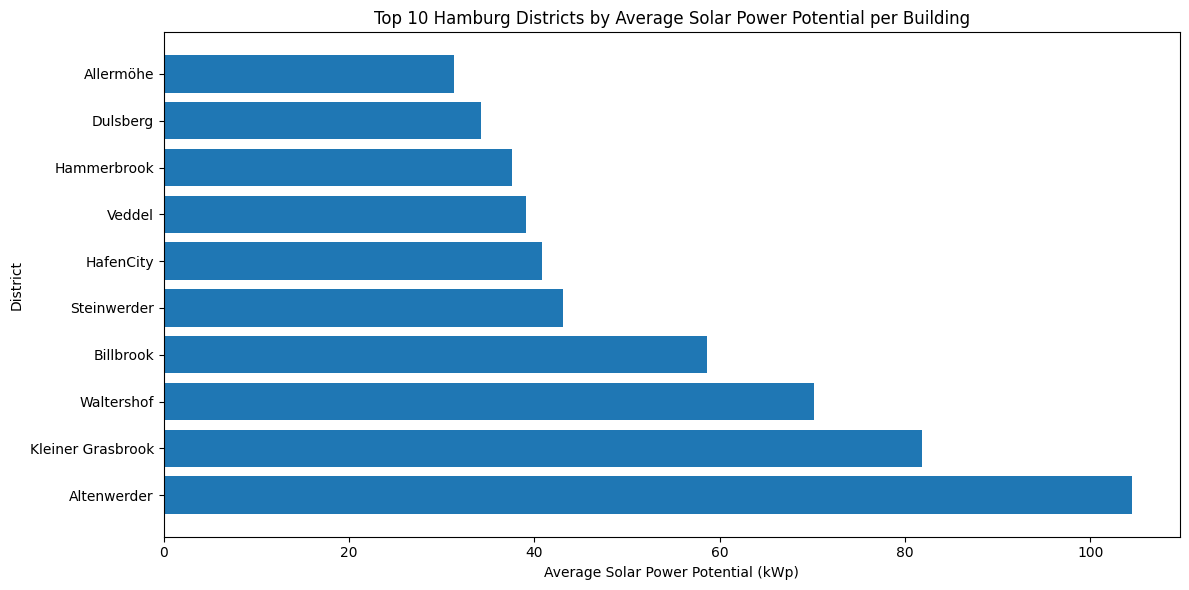

In [62]:
top10_avg = district_summary.sort_values(
    "avg_solar_power_kwp",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_avg["district"],
    top10_avg["avg_solar_power_kwp"]
)

plt.title(
    "Top 10 Hamburg Districts by Average Solar Power Potential per Building"
)

plt.xlabel("Average Solar Power Potential (kWp)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

*************************************************************************************

# **Top 10 Hamburg Districts by Solar Potential**

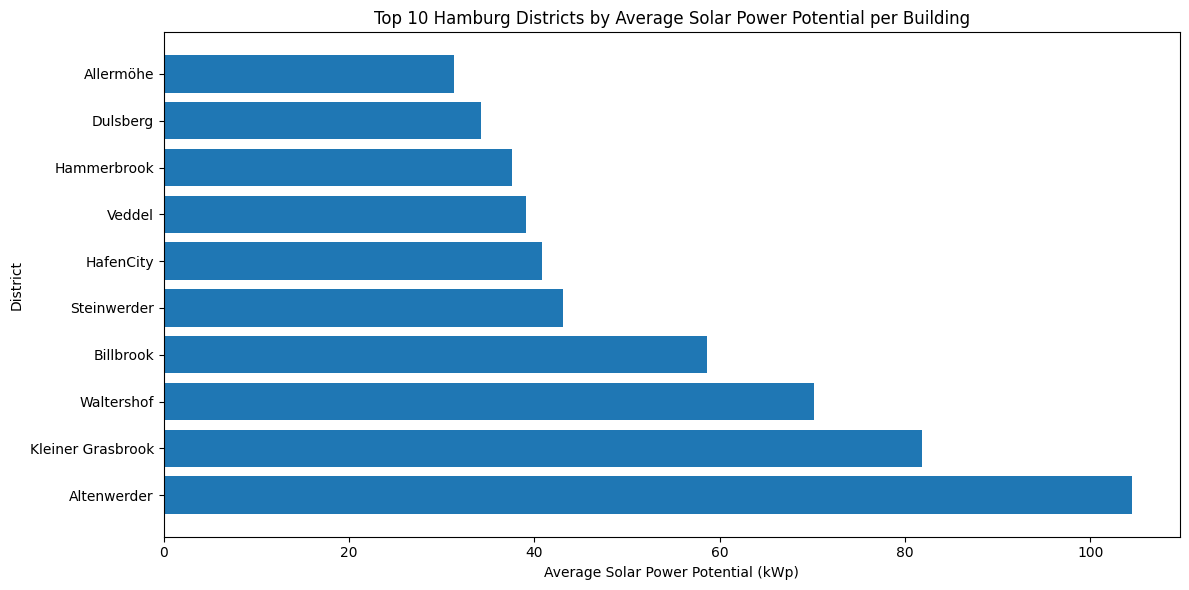

In [63]:
top10_avg = district_summary.sort_values(
    "avg_solar_power_kwp",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_avg["district"],
    top10_avg["avg_solar_power_kwp"]
)

plt.title(
    "Top 10 Hamburg Districts by Average Solar Power Potential per Building"
)

plt.xlabel("Average Solar Power Potential (kWp)")
plt.ylabel("District")

plt.tight_layout()
plt.show()

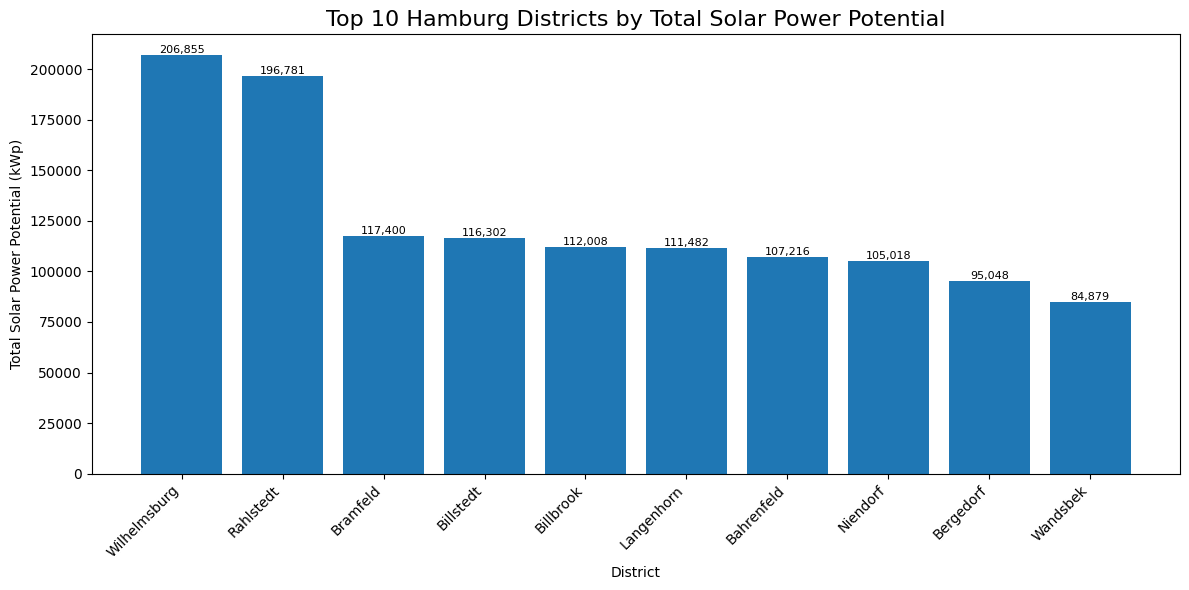

In [64]:
top10 = district_summary.sort_values(
    "total_solar_power_kwp",
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    top10["district"],
    top10["total_solar_power_kwp"]
)

ax.set_title(
    "Top 10 Hamburg Districts by Total Solar Power Potential",
    fontsize=16
)

ax.set_xlabel("District")
ax.set_ylabel("Total Solar Power Potential (kWp)")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [65]:
top10_avg[["district", "total_solar_power_kwp"]]

,district,total_solar_power_kwp
3,Altenwerder,48261.066993
49,Kleiner Grasbrook,37811.290873
96,Waltershof,38548.424660
11,Billbrook,112008.419598
87,Steinwerder,48724.265934
33,HafenCity,12256.979249
94,Veddel,38319.090882
36,Hammerbrook,31715.367801
19,Dulsberg,18370.299790
0,Allermöhe,49456.053444


# **Top 10 Districts by Suitability Percentage**

In [66]:
district_summary.sort_values(
    "suitability_percentage",
    ascending=False
).head(10)

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage
61,Neuenfelde,2248,39587.590858,17.610138,319453.44,142.105623,1935,86.08
38,Harvestehude,1531,22560.356794,14.735700,225027.79,146.980921,1317,86.02
17,Cranz,289,3382.987200,11.705838,24591.04,85.090104,247,85.47
50,Langenbek,1513,9792.603003,6.472309,69980.91,46.253080,1279,84.53
28,Francop,607,10080.435076,16.606977,73070.85,120.380313,512,84.35
42,Hoheluft-West,804,13157.726517,16.365331,123644.73,153.786978,675,83.96
23,Eimsbüttel,3169,54265.460978,17.123844,504057.53,159.058861,2634,83.12
41,Hoheluft-Ost,553,9801.977272,17.725095,98813.60,178.686438,458,82.82
15,Borgfelde,407,11776.118142,28.933951,111523.46,274.013415,336,82.56
4,Altona-Altstadt,1761,35806.103352,20.332824,325317.84,184.734719,1443,81.94


**Write a Clean Data into a CSV File For The Visualization**



In [67]:
district_summary.columns

Index(['district', 'number_of_buildings', 'total_solar_power_kwp',
       'avg_solar_power_kwp', 'total_solar_pvarea_m2', 'avg_pv_area',
       'suitable_buildings', 'suitability_percentage'],
      dtype='object')

In [68]:
district_summary.to_csv(path_or_buf="hamburg_solar_district_metrics.csv",index=False)

In [69]:
visual_df = pd.read_csv("hamburg_solar_district_metrics.csv")
visual_df.head()

,district,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage
0,Allermöhe,1578,49456.053444,31.340972,553940.23,351.039436,1190,75.41
1,Alsterdorf,2629,29044.794638,11.047849,262940.83,100.015531,1806,68.70
2,Altengamme,1617,16704.941494,10.330823,121865.86,75.365405,1232,76.19
3,Altenwerder,462,48261.066993,104.461184,532831.47,1153.314870,284,61.47
4,Altona-Altstadt,1761,35806.103352,20.332824,325317.84,184.734719,1443,81.94


In [70]:
print(visual_df.columns.tolist())

['district', 'number_of_buildings', 'total_solar_power_kwp', 'avg_solar_power_kwp', 'total_solar_pvarea_m2', 'avg_pv_area', 'suitable_buildings', 'suitability_percentage']


# **Check 1: Did we lose buildings?**

In [71]:
print("Buildings before join:", len(solar_gdf))
print("Buildings after join:", len(joined))

loss = len(solar_gdf) - len(joined)

print("Buildings not assigned to a district:", loss)
print(f"Percentage lost: {loss / len(solar_gdf) * 100:.4f}%")

Buildings before join: 384908
Buildings after join: 384525
Buildings not assigned to a district: 383
Percentage lost: 0.0995%


# **Result:**
383 / 384,908 = 0.000995
Meaning: 99.9% of all buildings were successfully assigned to a Hamburg district.

After performing the spatial join, 384,525 out of 384,908 buildings (99.9%) were successfully assigned to a Hamburg district. Only 383 buildings (0.1%) could not be matched, likely due to boundary or geometry inconsistencies. Therefore, the spatial join is considered highly reliable.

# **Why were 383 buildings lost?**
- Building polygon lies exactly on a district border.
- Tiny geometry inaccuracies between datasets.
- Some buildings are slightly outside the district boundaries.
- Small GIS/topology issues.

Therefore, This is completely normal in spatial analysis

# **Check 2: Which buildings were not assigned?**

In [72]:
missing = solar_gdf.loc[
    ~solar_gdf.index.isin(joined.index)
]

print("Missing buildings:", len(missing))
missing.head()

Missing buildings: 383


,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry
51,High,250331,11.858385,90.93,"POLYGON ((9.97027 53.58372, 9.97014 53.58384, ..."
624,High,384985,13.868900,143.40,"POLYGON ((10.04201 53.45645, 10.04219 53.45638..."
2016,Moderate,50798,1.289000,3.95,"POLYGON ((10.1048 53.61502, 10.10478 53.61509,..."
2277,Very High,186194,14.894087,222.91,"POLYGON ((9.9569 53.54741, 9.95722 53.54743, 9..."
3352,Very High,132220,25.629981,258.02,"POLYGON ((9.9589 53.55799, 9.95912 53.55796, 9..."


I checked which buildings were not assigned to a district. Only 383 out of 384,908 buildings (0.1%) could not be matched, likely due to boundary effects or minor geometry inconsistencies. Therefore, the district-level analysis is considered highly reliable.

# **Check 3: Did every district receive at least one building?**

In [73]:
assigned_districts = set(joined["district"].unique())
all_districts = set(districts_clean["district"].unique())

missing_districts = all_districts - assigned_districts

print("Districts with no assigned buildings:")
print(missing_districts)

Districts with no assigned buildings:
{'Neuwerk'}


Neuwerk exists in the district dataset.

Neuwerk does NOT appear in the joined dataset.

In [74]:
joined[joined["district"] == "Neuwerk"]

,suitability,building_id,solar_power_kwp,solar_pvarea_m2,geometry,index_right,district


In [75]:
assigned_districts = set(joined["district"].unique())
all_districts = set(districts_clean["district"].unique())

missing_districts = all_districts - assigned_districts

print("Missing districts:", missing_districts)
print("Number of missing districts:", len(missing_districts))

Missing districts: {'Neuwerk'}
Number of missing districts: 1


In [76]:
districts_clean[
    districts_clean["district"] == "Neuwerk"
]

,district,geometry
66,Neuwerk,"MULTIPOLYGON (((8.50426 53.92876, 8.50186 53.9..."


In [77]:
district_map[
    district_map["district"] == "Neuwerk"
]

,district,geometry,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage


# **Checking the code for myself :)**

In [78]:
assigned_districts = set(joined["district"].unique())
assigned_districts

{'Allermöhe',
 'Alsterdorf',
 'Altengamme',
 'Altenwerder',
 'Altona-Altstadt',
 'Altona-Nord',
 'Bahrenfeld',
 'Barmbek-Nord',
 'Barmbek-Süd',
 'Bergedorf',
 'Bergstedt',
 'Billbrook',
 'Billstedt',
 'Billwerder',
 'Blankenese',
 'Borgfelde',
 'Bramfeld',
 'Cranz',
 'Curslack',
 'Dulsberg',
 'Duvenstedt',
 'Eidelstedt',
 'Eilbek',
 'Eimsbüttel',
 'Eißendorf',
 'Eppendorf',
 'Farmsen-Berne',
 'Finkenwerder',
 'Francop',
 'Fuhlsbüttel',
 'Groß Borstel',
 'Groß Flottbek',
 'Gut Moor',
 'HafenCity',
 'Hamburg-Altstadt',
 'Hamm',
 'Hammerbrook',
 'Harburg',
 'Harvestehude',
 'Hausbruch',
 'Heimfeld',
 'Hoheluft-Ost',
 'Hoheluft-West',
 'Hohenfelde',
 'Horn',
 'Hummelsbüttel',
 'Iserbrook',
 'Jenfeld',
 'Kirchwerder',
 'Kleiner Grasbrook',
 'Langenbek',
 'Langenhorn',
 'Lemsahl-Mellingstedt',
 'Lohbrügge',
 'Lokstedt',
 'Lurup',
 'Marienthal',
 'Marmstorf',
 'Moorburg',
 'Moorfleet',
 'Neuallermöhe',
 'Neuenfelde',
 'Neuengamme',
 'Neugraben-Fischbek',
 'Neuland',
 'Neustadt',
 'Niendorf',


In [79]:
all_districts = set(districts_clean["district"].unique())
all_districts

{'Allermöhe',
 'Alsterdorf',
 'Altengamme',
 'Altenwerder',
 'Altona-Altstadt',
 'Altona-Nord',
 'Bahrenfeld',
 'Barmbek-Nord',
 'Barmbek-Süd',
 'Bergedorf',
 'Bergstedt',
 'Billbrook',
 'Billstedt',
 'Billwerder',
 'Blankenese',
 'Borgfelde',
 'Bramfeld',
 'Cranz',
 'Curslack',
 'Dulsberg',
 'Duvenstedt',
 'Eidelstedt',
 'Eilbek',
 'Eimsbüttel',
 'Eißendorf',
 'Eppendorf',
 'Farmsen-Berne',
 'Finkenwerder',
 'Francop',
 'Fuhlsbüttel',
 'Groß Borstel',
 'Groß Flottbek',
 'Gut Moor',
 'HafenCity',
 'Hamburg-Altstadt',
 'Hamm',
 'Hammerbrook',
 'Harburg',
 'Harvestehude',
 'Hausbruch',
 'Heimfeld',
 'Hoheluft-Ost',
 'Hoheluft-West',
 'Hohenfelde',
 'Horn',
 'Hummelsbüttel',
 'Iserbrook',
 'Jenfeld',
 'Kirchwerder',
 'Kleiner Grasbrook',
 'Langenbek',
 'Langenhorn',
 'Lemsahl-Mellingstedt',
 'Lohbrügge',
 'Lokstedt',
 'Lurup',
 'Marienthal',
 'Marmstorf',
 'Moorburg',
 'Moorfleet',
 'Neuallermöhe',
 'Neuenfelde',
 'Neuengamme',
 'Neugraben-Fischbek',
 'Neuland',
 'Neustadt',
 'Neuwerk',
 

In [80]:
missing_districts = all_districts - assigned_districts
missing_districts

{'Neuwerk'}

# **Neuwerk exists in Hamburg's district map but does not appear in the joined building dataset.**

In [81]:
districts_clean[
    districts_clean["district"] == "Neuwerk"
]

,district,geometry
66,Neuwerk,"MULTIPOLYGON (((8.50426 53.92876, 8.50186 53.9..."


# **Neuwerk exists in the GeoJSON file.**

In [82]:
district_map[
    district_map["district"] == "Neuwerk"
]

,district,geometry,number_of_buildings,total_solar_power_kwp,avg_solar_power_kwp,total_solar_pvarea_m2,avg_pv_area,suitable_buildings,suitability_percentage


# **Empty DataFrame!**

# **Finding:**
- 384,908 buildings before join
- 384,525 buildings after join
- 383 buildings lost

# **Why is this not a problem?**
- Total districts = 104
- Assigned districts = 103
- Missing districts = 1
- 103 / 104 = 99.0%
- 384,525 / 384,908 = 99.9%

I compared the districts in the Hamburg boundary dataset with those represented in the joined building dataset. Out of 104 Hamburg districts, 103 received at least one building assignment. The only missing district was Neuwerk, a small island district outside Hamburg's main urban area. Therefore, the spatial coverage of the analysis is considered nearly complete.

In [83]:
print(
    joined["district"].nunique()
)

print(
    districts_clean["district"].nunique()
)

103
104
